![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Final Project

## 0. Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength

c=3*10^8 # m/s


In [4]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Componentes Básicos

### LO.1. Effective index of a waveguide (Waveguide compact model)


#### Narrow waveguide 450 nm

In [5]:
wavelengthIni=1.5
wavelengthFin=1.6


wavelength = np.linspace(wavelengthIni, wavelengthFin,30) 

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=450*nm, 
    slab_thickness=0*nm,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.6,
    grid_resolution=40, 
)



Text(0.5, 1.0, 'Sección transversal de la guía de onda estrecha \n (450 nm)')

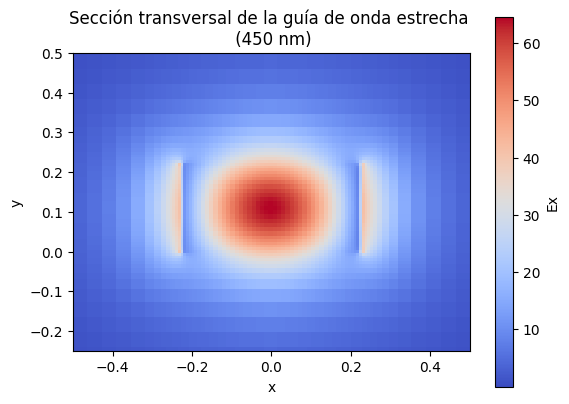

In [8]:
deep_waveguide.plot_field(mode_index=0 , 
                          field_name='Ex', 
                          value='real', 
                            cmap='coolwarm', 
                          xlim=(-0.5, 0.5), 
                          ylim=(-0.25, 0.5)
) # 
plt.title('Sección transversal de la guía de onda estrecha \n (450 nm)') 

In [9]:
res_neff = deep_waveguide.n_eff 
res_te = deep_waveguide.fraction_te 
res_tm = deep_waveguide.fraction_tm 
print(f"La fracción correspondiente a TE de los modos es: {res_te}")
print(f"La fracción correspondiente a TM de los modos es: {res_tm}")

La fracción correspondiente a TE de los modos es: [0.97021084 0.06553376 0.64112163 0.9976657 ]
La fracción correspondiente a TM de los modos es: [0.02978916 0.93446624 0.35887837 0.0023343 ]


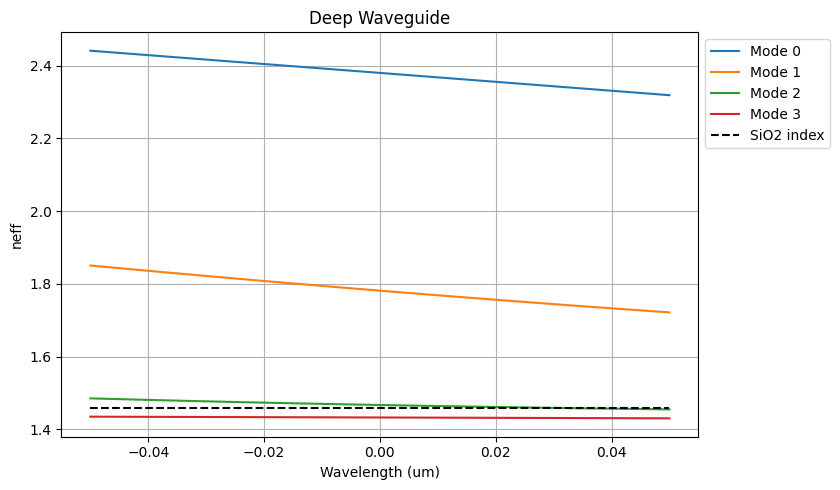

In [10]:
plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    plt.plot(wavelength-1.55, res_neff[:,k].real,label=f'Mode {k}')

plt.title(f"Deep Waveguide")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength-1.55, 1.4577374304687887*np.ones(len(wavelength)),'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])


Como se observa, solo los modos 0 y 1 se porpagan en las longitudes de onda de 1500 a 1600 nm, el modo 2 se propaga en longitudes de onda cercanas a 1500 nm, pero luego deja de propagarse. Adicionalmente, la fracción de modo TE y TM, mostró que el modo 0 corresponde a un modo TE y el modo 1 es TM. 

In [11]:
#Los parámetros correspondientes al comportamiento del modo TE0 son:


[n3_E0,n2_E0,n1_E0]=np.polyfit(wavelength-1.55, res_neff[:,0].real, 2)

n_eff_E0=n1_E0
n_g_E0=n1_E0-n2_E0*1550*nm
D_E0=-(2*1550*nm*n3_E0)/c

print(f"n_eff_E0 = {n_eff_E0}")
print(f"n_g_E0 = {n_g_E0}")
print(f"D _E0= {D_E0}")

n_eff_E0 = 2.380296138058214
n_g_E0 = 4.2766018525352845
D _E0= 0.005701973668497861


In [12]:
#Para el modo TM0:


[n3_M0,n2_M0,n1_M0]=np.polyfit(wavelength-1.55, res_neff[:,1].real, 2)

n_eff_M0=n1_M0
n_g_M0=n1_M0-n2_M0*1550*nm
D_M0=-(2*1550*nm*n3_M0)/c

print(f"n_eff_M0 = {n_eff_M0}")
print(f"n_g_M0 = {n_g_M0}")
print(f"D_M0 = {D_M0}")

n_eff_M0 = 1.781468166760508
n_g_M0 = 3.7806600626293005
D_M0 = -0.26192517374835395


Ahora, se comprueba que la aproximación de los parámetros si de como resultado la gráfica obtenida anteriormente de indice efectivo para los modos TE0 y TM0.

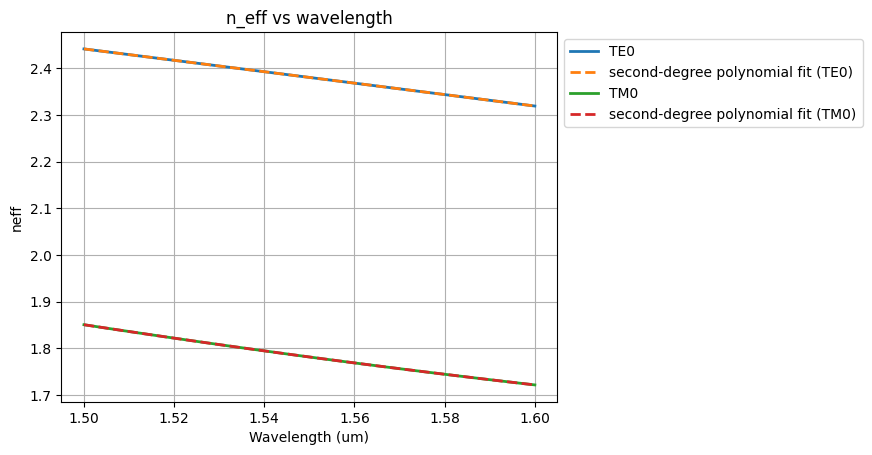

In [13]:

n_eff_func_E0=[]
n_eff_func_M0=[]
for i in range(0,len(wavelength),1):
    lamd_wa=wavelength[i]-1.55
    n_eff_func_E0.append(n1_E0+n2_E0*lamd_wa+n3_E0*(lamd_wa**2))
    n_eff_func_M0.append(n1_M0+n2_M0*lamd_wa+n3_M0*(lamd_wa**2))

plt.plot(wavelength, res_neff[:,0].real,linewidth=2,label = 'TE0')
plt.plot(wavelength, n_eff_func_E0,linestyle='--',label = 'second-degree polynomial fit (TE0) ', linewidth=2)
plt.plot(wavelength, res_neff[:,1].real,linewidth=2,label = 'TM0')
plt.plot(wavelength, n_eff_func_M0,linestyle='--',label = 'second-degree polynomial fit (TM0)', linewidth=2)
plt.title(f"n_eff vs wavelength")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()


#### Wide waveguide 650 nm

In [14]:
wavelength = np.linspace(wavelengthIni, wavelengthFin,30) 

deep_waveguide_w = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=650*nm, 
    slab_thickness=0*nm,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.6,
    grid_resolution=30, 
)



2026-05-23 14:33:45.887 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a9026f1ded1213c5.npz.


Text(0.5, 1.0, 'Sección transversal de la guía de onda ancha \n (650 nm)')

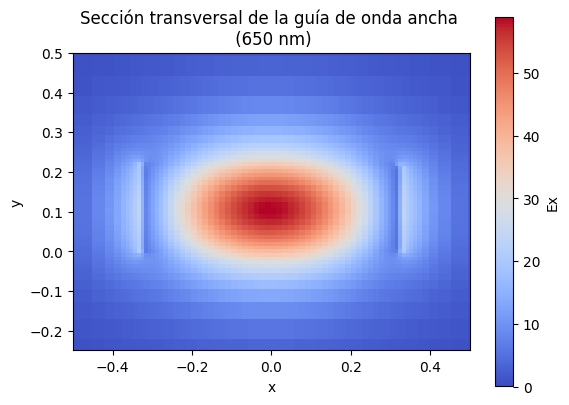

In [15]:
deep_waveguide_w.plot_field(mode_index=0 , 
                          field_name='Ex', 
                          value='real', 
                            cmap='coolwarm', 
                          xlim=(-0.5, 0.5), 
                          ylim=(-0.25, 0.5)
) # 
plt.title('Sección transversal de la guía de onda ancha \n (650 nm)') 

In [16]:
res_neff_w = deep_waveguide_w.n_eff 
res_te_w = deep_waveguide_w.fraction_te 
res_tm_w = deep_waveguide_w.fraction_tm 
print(f"La fracción correspondiente a TE de los modos es: {res_te}")
print(f"La fracción correspondiente a TE de los modos es: {res_tm}")

La fracción correspondiente a TE de los modos es: [0.97021084 0.06553376 0.64112163 0.9976657 ]
La fracción correspondiente a TE de los modos es: [0.02978916 0.93446624 0.35887837 0.0023343 ]


Para este caso, tambien el modo TE0 corresponderá al modo 0 y el modo 1 será el TM0.

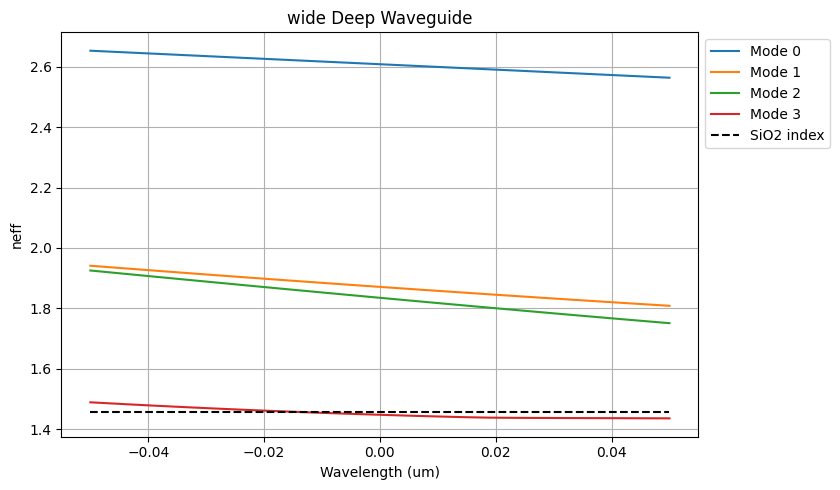

In [17]:
plt.figure(figsize=(10, 5))
for k in range(res_neff_w.shape[1]):
    plt.plot(wavelength-1.55, res_neff_w[:,k].real,label=f'Mode {k}')

plt.title(f"wide Deep Waveguide")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength-1.55, 1.4577374304687887*np.ones(len(wavelength)),'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])


Al tener un mayor ancho, se propagan más modos, de manera que el modo 2 se propaga en todas las longitudes de onda del intervalo, mientras que el 3 se propaga al inicio de este. 

In [18]:

#Los parámetros para el modo TE0:
[n3_E0_w,n2_E0_w,n1_E0_w]=np.polyfit(wavelength-1.55, res_neff[:,0].real, 2)

n_eff_E0_w=n1_E0_w
n_g_E0_w=n1_E0_w-n2_E0_w*1550*nm
D_E0_w=-(2*1550*nm*n3_E0_w)/c

print(f"n_eff_E0_w = {n_eff_E0_w}")
print(f"n_g_E0_w = {n_g_E0_w}")
print(f"D_w = {D_E0_w}")


n_eff_E0_w = 2.380296138058214
n_g_E0_w = 4.2766018525352845
D_w = 0.005701973668497861


In [19]:
#Para el modo TM0:

[n3_M0_w,n2_M0_w,n1_M0_w]=np.polyfit(wavelength-1.55, res_neff[:,1].real, 2)

n_eff_M0_w=n1_M0_w
n_g_M0_w=n1_M0_w-n2_M0_w*1550*nm
D_M0_w=-(2*1550*nm*n3_M0_w)/c

print(f"n_eff_M0 = {n_eff_M0_w}")
print(f"n_g_M0 = {n_g_M0_w}")
print(f"D_M0 = {D_M0_w}")

n_eff_M0 = 1.781468166760508
n_g_M0 = 3.7806600626293005
D_M0 = -0.26192517374835395


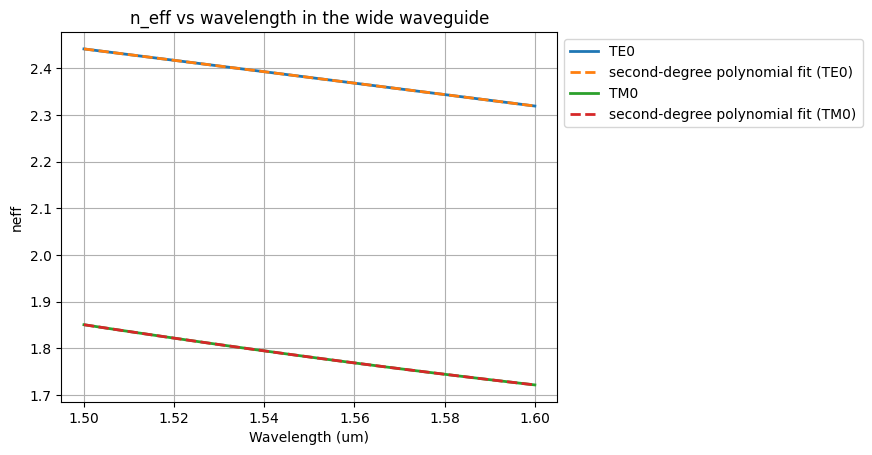

In [20]:

n_eff_func_E0_w=[]
n_eff_func_M0_w=[]
for i in range(0,len(wavelength),1):
    lamd_wa=wavelength[i]-1.55
    n_eff_func_E0_w.append(n1_E0_w+n2_E0_w*lamd_wa+n3_E0_w*(lamd_wa**2))
    n_eff_func_M0_w.append(n1_M0_w+n2_M0_w*lamd_wa+n3_M0_w*(lamd_wa**2))

plt.plot(wavelength, res_neff[:,0].real,linewidth=2,label = 'TE0')
plt.plot(wavelength, n_eff_func_E0_w,linestyle='--',label = 'second-degree polynomial fit (TE0) ', linewidth=2)
plt.plot(wavelength, res_neff[:,1].real,linewidth=2,label = 'TM0')
plt.plot(wavelength, n_eff_func_M0_w,linestyle='--',label = 'second-degree polynomial fit (TM0)', linewidth=2)
plt.title(f"n_eff vs wavelength in the wide waveguide")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()


### Directional Coupler

Para hallar las diferentes constantes de acoplo que se proponen en el artículo, que son 0.5, 0.17, 0.23, 0.05, 0.3 vamos a guiarnos por la siguiente formula:

$$K=sin^2\left(\frac{1}{2} \pi\left(\frac{L}{L_{\pi}}\right)\right)$$

Despejando:

$$\sqrt{K}=sin\left(\frac{1}{2} \pi\left(\frac{L}{L_{\pi}}\right)\right)$$

$$\arcsin\left(\sqrt{K}\right)=\frac{1}{2} \pi\left(\frac{L}{L_{\pi}}\right)$$
$$L=\frac{2}{\pi} \arcsin\left(\sqrt{K}\right)*L_{\pi}$$

Luego, para las diferentes constantes de acoplo que se toman en el ejercicio:


In [21]:
K_array=[0.5, 0.17, 0.23, 0.05, 0.3]
LL_pi_array=[]
for i in range(0,len(K_array),1):
    Long=(2/np.pi)*np.arcsin(np.sqrt(K_array[i]))
    LL_pi_array.append(Long)
print(f"Nuestras constantes de acoplo buscadas son: {K_array}")
print(f"Luego la relacion de L/L_pi para cada k es: {np.round(LL_pi_array,2)}")

Nuestras constantes de acoplo buscadas son: [0.5, 0.17, 0.23, 0.05, 0.3]
Luego la relacion de L/L_pi para cada k es: [0.5  0.27 0.32 0.14 0.37]


In [22]:
# Vamos a variar el gap para así ver como afecta el gap el L_pi, adicionalmente los DC tendrán un ancho de las guias de onda de 450 nm
gap_to_simulate = (1/10)*np.linspace(1, 5, 9) 
                           
wavelength=1.55
L_pi_TE=[]
L_pi_TM=[]

for i in range(0,len(gap_to_simulate),1):
    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Wavelength to simulate - Must be a vector
        core_width=(450*nm, 450*nm), # Waveguide width
        gap=gap_to_simulate[i],
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=220 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.6, # Parameters of the grid
        grid_resolution=40 # Parameters of the grid
    )

    dcoupler_neff = deep_dcoupler_cs.n_eff
    #print("------Fraction of TE-----")
    #print(deep_dcoupler_cs.fraction_te)
    # TE Modes: Modes 0 & 1
    L_pi_TE.append( 0.5*wavelength/(dcoupler_neff[0].real-dcoupler_neff[1].real))
    L_pi_TM.append( 0.5*wavelength/(dcoupler_neff[2].real-dcoupler_neff[3].real))



/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalprojec

2026-05-23 14:34:18.856 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_dbfc81237072f170.npz.
2026-05-23 14:34:18.895 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_3e83b4936720a721.npz.
2026-05-23 14:34:18.901 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_06f330d7a0f3b308.npz.


/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalprojec

2026-05-23 14:34:25.898 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_c5f73e9c17e70198.npz.


/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalprojec

...

2026-05-23 14:34:48.802 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_7527f47ebbf3d748.npz.
2026-05-23 14:34:48.861 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9de0199d768e45b3.npz.


/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalprojec

2026-05-23 14:35:03.324 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_dc7ad61c4095c90d.npz.


/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalproject-Paula-Daniela-Ortiz/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab5-finalprojec

2026-05-23 14:35:28.500 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_d4d246763af66c4b.npz.


L_pi_TE para cada gap es: [ 10.062  15.354  24.833  37.892  57.487  86.927  61.298 197.534 296.889]


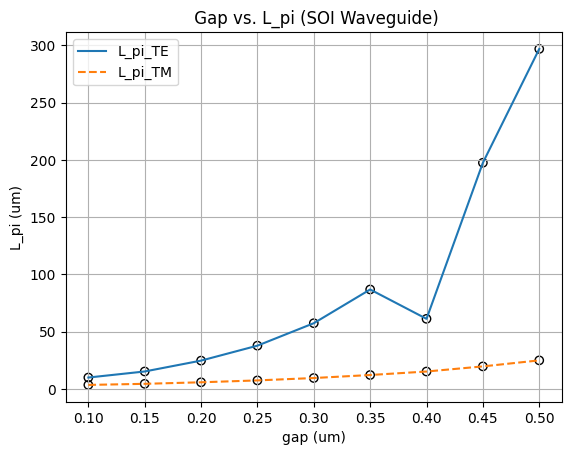

In [24]:
print(f"L_pi_TE para cada gap es: {np.round(L_pi_TE,3)}")
plt.plot(gap_to_simulate,L_pi_TE ,label="L_pi_TE")
plt.scatter(gap_to_simulate, L_pi_TE,edgecolors='k',facecolors='none',label = '_nolegend_')
plt.plot(gap_to_simulate, L_pi_TM,label="L_pi_TM", linestyle="--")
plt.scatter(gap_to_simulate, L_pi_TM,edgecolors='k',facecolors='none',label = '_nolegend_')
plt.title(" Gap vs. L_pi (SOI Waveguide)")
plt.xlabel("gap (um)")
plt.ylabel("L_pi (um)")
plt.legend()
plt.grid()

Como sabemos, no se debe tomar un gap tan pequeño porque a la hora de fabricar se vuelve más critico. Por ello se selecciónó un gap de 0.35 um, ya que, permite que la distancia L_pi, no sea tan grande, ya que despues de este valor, se observa que el crecimiento de la longitud de acoplamiento aumenta significativamente, pues mientras que en 0.35 um de gap, la distancia esta cerca de los 100 um, a los 0.5 um de gap ese valor se triplica.  

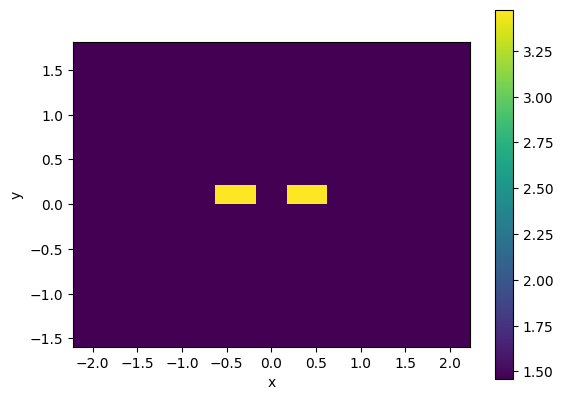

In [25]:
dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(450*nm, 450*nm), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=220 * nm, # Waveguide height 
    gap=350 * nm,
    #gap=500*nm,
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=wavelength, # Wavelength to simulate
    num_modes=6, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.6, # Parameters of the grid
    grid_resolution=40 # Parameters of the grid
)

dcoupler_cs.plot_index()

Text(0.5, 1.0, 'Sección transversal del acoplador direccional')

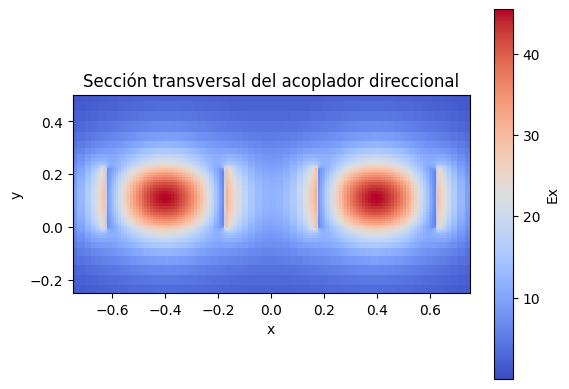

In [27]:
dcoupler_cs.plot_field(mode_index=0 , 
                          field_name='Ex', 
                          value='real', 
                            cmap='coolwarm', 
                          xlim=(-0.75, 0.75), 
                          ylim=(-0.25, 0.5)
) # 
plt.title('Sección transversal del acoplador direccional') 

Para hallar las longitudes de acoplo voy a dejar el gap fijo, de manera que a la hora de fabricar no se generen distancias muy pequeñas de gap para conseguir diferentes acoplos, de manera que las longitudes serían las siguientes:

In [28]:
gap_select=0.35
#gap_select=0.5
index = np.where(gap_to_simulate == gap_select)[0]
index= np.argmin(np.abs(gap_to_simulate - gap_select))
L_pi_select=L_pi_TE[index]
Length_DC=[x * L_pi_select for x in LL_pi_array]

K_final=[(np.sin((1/2)*np.pi*(x/L_pi_select)))**2 for x in Length_DC]


print(f"Las longitudes con un gap de 0.35 um para tener los acoplos son: {np.round(Length_DC,3)}")
print(f"Nuestras constantes de acoplo buscadas son: {np.round(K_final,3)}")


Las longitudes con un gap de 0.35 um para tener los acoplos son: [43.464 23.519 27.68  12.48  32.077]
Nuestras constantes de acoplo buscadas son: [0.5  0.17 0.23 0.05 0.3 ]


Luego de hacer la simulación con la librería de *upvfab_design_tools* de el acoplador direccional, se optimizarón las distancias para que las constantes de acoplo dierán lo más parecido a las buscadas, en donde se les dío una distacia de corrección, dado los siguientes resultados:

In [29]:
Length_DC=[43.464+0.15, 23.519+0.28, 27.68+0.25,  12.48+0.27,  32.077+0.6]

K_final=[0.4912, 0.1705,0.2325,0.0496,0.3068]


print(f"Las longitudes con un gap de 0.35 um para tener los acoplos son: {np.round(Length_DC,3)}")
print(f"Nuestras constantes de acoplo buscadas son: {np.round(K_final,4)}")


Las longitudes con un gap de 0.35 um para tener los acoplos son: [43.614 23.799 27.93  12.75  32.677]
Nuestras constantes de acoplo buscadas son: [0.4912 0.1705 0.2325 0.0496 0.3068]


## Components S matrix

### Parámetros/funciones importantes

Ahora, es necesario definir las estructuras básicas de la arquetectura, en donde se usan los MZI, estas estructuras básicas son:

- Guias de onda 
- DC

In [30]:
import sax
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
# Waveguide Model
wl0=1.55
#n_eff_wv0=n1_E0_w+n2_E0_w*wl0+n3_E0_w*(wl0**2)

def waveguide(wl=wl0, neff=n_eff_E0,n_g=n_g_E0,D=D_E0, length=10.0, loss=0.0) -> sax.SDict:
    n_eff=neff+n_g*(wl-wl0)+D*(wl-wl0)**2
    #n_eff=neff --> con este ya sirve
    phase = 2 * jnp.pi * n_eff * length / wl 
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict


# Coupler Model
def coupler(coupling=0.5,loss_db=0) -> sax.SDict:
    coup = coupling
    loss = 10**(-loss_db/20)
    kappa = (coupling**0.5)*loss
    tau = ((1 - coupling)**0.5)*loss
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

Para el MZI vamos a tener dos longitudes, una para cada brazo y estarán dadas por $L_1$ y $L_2$, y deben escogerse deacuerdo a:

$$m \lambda_0=n_1L_1-n_2L_2$$

despejando $L_1-L_2$ y teniendo en cuenta que $n_1=n_2$:

$$m \lambda_0=n_1(L_1-L_2)$$
$$(L_1-L_2)=\frac{n_1}{m \lambda _0}$$

Además nos dice que debe ser el FSR=40nm y el FSR esta dado por:

$$FSR=(\lambda _0^2)/(\Delta L*n_{g_{1550}})$$
$$\Delta L=(\lambda _0^2)/(FSR*n_{g_{1550}})$$

In [31]:
FSR=40*nm

deltaL=(wl0**2)/(FSR*n_g_E0)
print(f"--------- para un FSR={FSR/nm} nm -----------")
print(f"La diferencia entre las longitudes de los caminos debe ser de: {deltaL}")
L1=20
L2=L1-deltaL

#L1=23.25
#L2=8.014
#deltaL=L1-L2
#
print(f"Así L_1 es: {L1}")
print(f"Así L_2 es: {np.round(L2,3)}")

FSR_s2=80*nm

deltaL_s2=(wl0**2)/(FSR_s2*n_g_E0)
print(f"--------- para un FSR={FSR_s2/nm} nm -----------")
print(f"La diferencia entre las longitudes de los caminos debe ser de: {deltaL_s2}")
L1_s2=20
L2_s2=L1_s2-deltaL_s2
#L1_s2=L1
#L2_s2=L1-deltaL/2
print(f"Así L_1 es: {L1_s2}")
print(f"Así L_2 es: {np.round(L2_s2,3)}")

--------- para un FSR=40.0 nm -----------
La diferencia entre las longitudes de los caminos debe ser de: 14.044445115785877
Así L_1 es: 20
Así L_2 es: 5.956
--------- para un FSR=80.0 nm -----------
La diferencia entre las longitudes de los caminos debe ser de: 7.022222557892938
Así L_1 es: 20
Así L_2 es: 12.978


### Prueba de cada uno de los bloques (s1, s2)

Una vez conocemos como deben ser las longitudes deacuerdo al FSR podemos definir cada bloque del circuito y simular su comportamiento.


In [32]:
# MZI

S1, info = sax.circuit(
    netlist={
        "instances": {  
            "coup_a": "coupler",
            "wvg_u1": "waveguide",
            "wvg_d1": "waveguide",
            "coup_b": "coupler",
            "wvg_u2": "waveguide",
            "wvg_d2": "waveguide",
            "coup_c": "coupler",
            "wvg_u3": "waveguide",
            "wvg_d3": "waveguide",
            "coup_d": "coupler",
        },
        "connections": {
            "coup_a,out0": "wvg_d1,in0",
            "wvg_d1,out0": "coup_b,in0",
            "coup_a,out1": "wvg_u1,in0",
            "wvg_u1,out0": "coup_b,in1",
            #--------------------------
            "coup_b,out0": "wvg_d2,in0",
            "wvg_d2,out0": "coup_c,in0",
            "coup_b,out1": "wvg_u2,in0",
            "wvg_u2,out0": "coup_c,in1",
            #--------------------------
            "coup_c,out0": "wvg_d3,in0",
            "wvg_d3,out0": "coup_d,in0",
            "coup_c,out1": "wvg_u3,in0",
            "wvg_u3,out0": "coup_d,in1",
        },
        "ports": { 
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_d,out0",
            "out1": "coup_d,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

In [33]:
import jax.numpy as jnp
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

wvl_arr = np.linspace(wavelengthIni, wavelengthFin,30) 

interp_neffu = interp1d(wvl_arr, n_eff_func_E0_w, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl_arr, n_eff_func_E0, kind='cubic')
wvl = np.linspace(wvl_arr.min(), wvl_arr.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

#neffu = jnp.array(n_eff_func_E0)
#neffd = jnp.array(n_eff_func_E0)
alphau = jnp.zeros_like(wvl)
alphad = jnp.zeros_like(wvl)

L_pi_select=1.55/(2*n_eff_E0)

S1_test = S1(
            coup_a={"coupling":np.full(wvl.shape, K_final[0])},
            wvg_u1={"wl":wvl, "neff":neffu, "length": L1, "loss":alphau},
            wvg_d1={"wl":wvl, "neff":neffd, "length": L2, "loss":alphad},
            coup_b={"coupling":np.full(wvl.shape, K_final[1])},
            wvg_u2={"wl":wvl, "neff":neffu, "length": 2*L2, "loss":alphau},
            wvg_d2={"wl":wvl, "neff":neffd, "length": 2*L1, "loss":alphad},
            coup_c={"coupling":np.full(wvl.shape, K_final[2])},
            wvg_u3={"wl":wvl, "neff":neffu, "length": 2*L2, "loss":alphau},
            wvg_d3={"wl":wvl, "neff":neffd, "length": 2*L1+L_pi_select, "loss":alphad},
            coup_d={"coupling":np.full(wvl.shape, K_final[3])},
            )

h00 = S1_test["in0", "out0"]
h01 = S1_test["in0", "out1"]
h11 = S1_test["in1", "out1"]
h10 = S1_test["in1", "out0"]

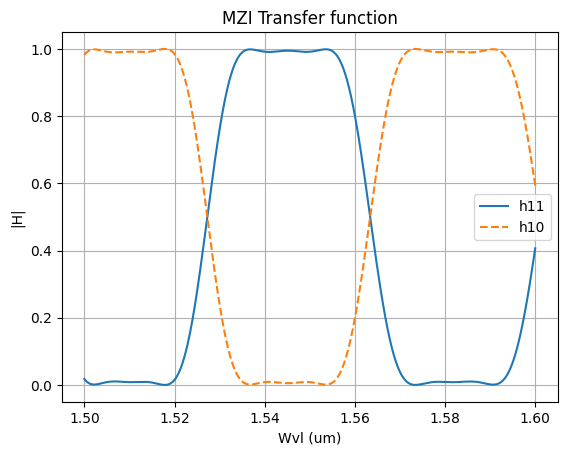

In [34]:
# Plot
plt.figure()
plt.plot(wvl, np.abs(h11)**2, linestyle="-", label=f"h11")
plt.plot(wvl, np.abs(h10)**2, linestyle="--", label=f"h10")
#plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
#plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()


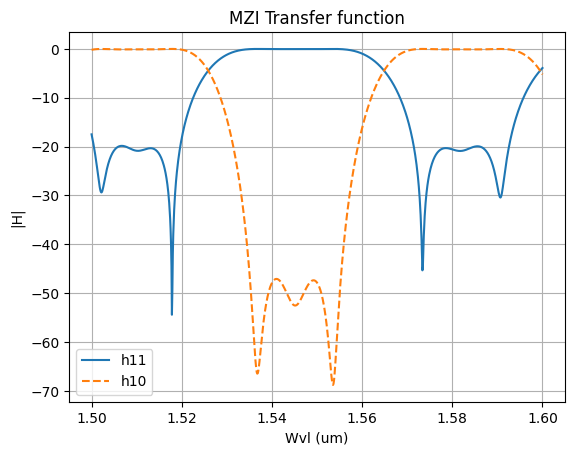

In [35]:
# Plot
plt.figure()
plt.plot(wvl, 10*np.log10(np.abs(h11)**2), linestyle="-", label=f"h11")
plt.plot(wvl, 10*np.log(np.abs(h10)**2), linestyle="--", label=f"h10")
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()

In [36]:
# MZI

S2, info = sax.circuit(
    netlist={
        "instances": {  
            "coup_a": "coupler",
            "wvg_u1": "waveguide",
            "wvg_d1": "waveguide",
            "coup_b": "coupler",
            "wvg_u2": "waveguide",
            "wvg_d2": "waveguide",
            "coup_c": "coupler",
        },
        "connections": {
            "coup_a,out0": "wvg_d1,in0",
            "wvg_d1,out0": "coup_b,in0",
            "coup_a,out1": "wvg_u1,in0",
            "wvg_u1,out0": "coup_b,in1",
            "coup_b,out0": "wvg_d2,in0",
            "wvg_d2,out0": "coup_c,in0",
            "coup_b,out1": "wvg_u2,in0",
            "wvg_u2,out0": "coup_c,in1",
        },
        "ports": { 
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_c,out0",
            "out1": "coup_c,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

In [37]:
import jax.numpy as jnp
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

wvl_arr = np.linspace(wavelengthIni, wavelengthFin,30) 

interp_neffu = interp1d(wvl_arr, n_eff_func_E0, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl_arr, n_eff_func_E0, kind='cubic')
wvl = np.linspace(wvl_arr.min(), wvl_arr.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

#neffu = jnp.array(n_eff_func_E0)
#neffd = jnp.array(n_eff_func_E0)
alphau = jnp.zeros_like(wvl)
alphad = jnp.zeros_like(wvl)


S2_test = S2(
            coup_a={"coupling":np.full(wvl.shape, K_final[0])},
            wvg_u1={"wl":wvl, "neff":neffu, "length": L1, "loss":alphau},
            wvg_d1={"wl":wvl, "neff":neffd, "length": L2, "loss":alphad},
            coup_b={"coupling":np.full(wvl.shape, K_final[4])},
            wvg_u2={"wl":wvl, "neff":neffu, "length": 2*L2, "loss":alphau},
            wvg_d2={"wl":wvl, "neff":neffd, "length": 2*L1, "loss":alphad},
            coup_c={"coupling":np.full(wvl.shape, K_final[3])},
            )

h00_s2 = S2_test["in0", "out0"]
h01_s2 = S2_test["in0", "out1"]
h11_s2 = S2_test["in1", "out1"]
h10_s2 = S2_test["in1", "out0"]

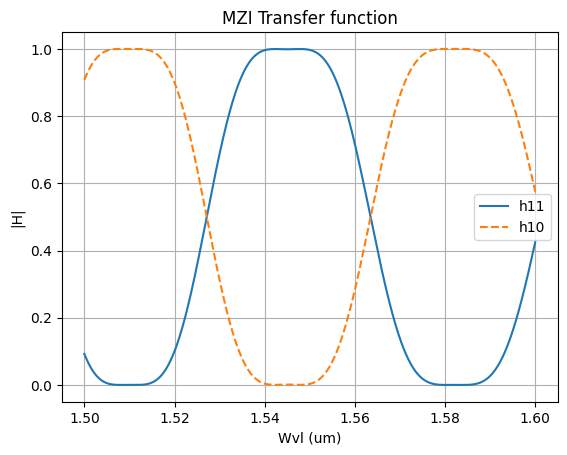

In [38]:
# Plot
plt.figure()
plt.plot(wvl, np.abs(h11_s2)**2, linestyle="-", label=f"h11")
plt.plot(wvl, np.abs(h10_s2)**2, linestyle="--", label=f"h10")
#plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
#plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()

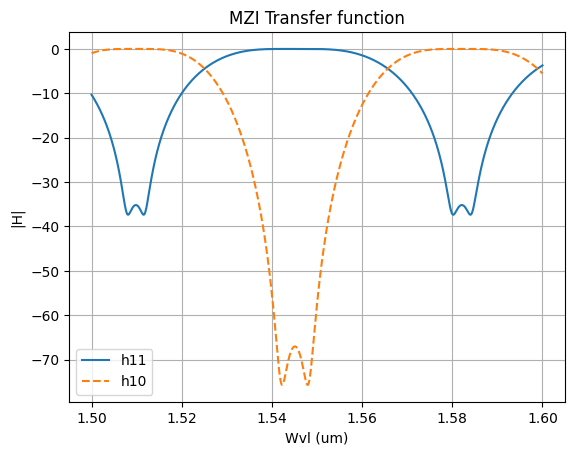

In [39]:
# Plot
plt.figure()
plt.plot(wvl, 10*np.log10(np.abs(h11_s2)**2), linestyle="-", label=f"h11")
plt.plot(wvl, 10*np.log(np.abs(h10_s2)**2), linestyle="--", label=f"h10")
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()

In [40]:
import jax.numpy as jnp
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

wvl_arr = np.linspace(wavelengthIni, wavelengthFin,30) 
print(n_eff_func_E0)
interp_neffu = interp1d(wvl_arr, n_eff_func_E0_w, kind='cubic')  # Cubic interpolation for smoothness
interp_neffd = interp1d(wvl_arr, n_eff_func_E0, kind='cubic')
wvl = np.linspace(wvl_arr.min(), wvl_arr.max(), 1000)
neffu = interp_neffu(wvl)
neffd = interp_neffd(wvl)

#neffu = jnp.array(n_eff_func_E0)
#neffd = jnp.array(n_eff_func_E0)
alphau = jnp.zeros_like(wvl)
alphad = jnp.zeros_like(wvl)


S3_test = S2(
            coup_a={"coupling":np.full(wvl.shape, K_final[0])},
            wvg_u1={"wl":wvl, "neff":neffu, "length": L1+0.5*L_pi_select, "loss":alphau},
            wvg_d1={"wl":wvl, "neff":neffd, "length": L2+0.5*L_pi_select, "loss":alphad},
            coup_b={"coupling":np.full(wvl.shape, K_final[4])},
            wvg_u2={"wl":wvl, "neff":neffu, "length": 2*(L2+0.5*L_pi_select), "loss":alphau},
            wvg_d2={"wl":wvl, "neff":neffd, "length": 2*(L1+0.5*L_pi_select), "loss":alphad},
            coup_c={"coupling":np.full(wvl.shape, K_final[3])},
            )

h00_s3 = S3_test["in0", "out0"]
h01_s3 = S3_test["in0", "out1"]
h11_s3 = S3_test["in1", "out1"]
h10_s3 = S3_test["in1", "out0"]

[np.float64(2.441366126089162), np.float64(2.4371608984468898), np.float64(2.432954708483105), np.float64(2.4287475561978082), np.float64(2.4245394415909995), np.float64(2.4203303646626786), np.float64(2.4161203254128454), np.float64(2.4119093238415004), np.float64(2.4076973599486426), np.float64(2.403484433734274), np.float64(2.3992705451983922), np.float64(2.3950556943409986), np.float64(2.3908398811620932), np.float64(2.3866231056616756), np.float64(2.382405367839746), np.float64(2.3781866676963044), np.float64(2.3739670052313504), np.float64(2.3697463804448846), np.float64(2.3655247933369066), np.float64(2.3613022439074167), np.float64(2.357078732156414), np.float64(2.3528542580839003), np.float64(2.3486288216898736), np.float64(2.344402422974335), np.float64(2.340175061937285), np.float64(2.3359467385787225), np.float64(2.3317174528986477), np.float64(2.327487204897061), np.float64(2.3232559945739624), np.float64(2.3190238219293513)]


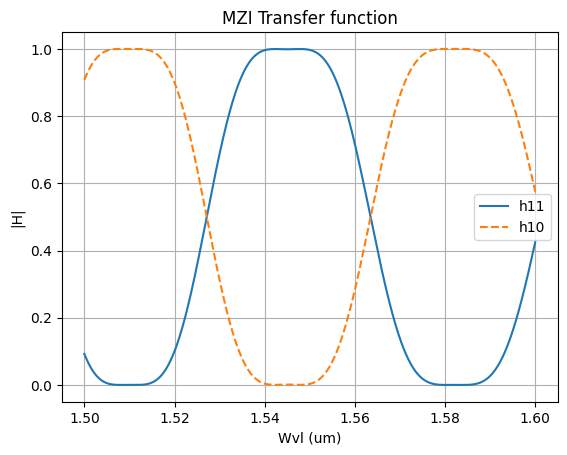

In [41]:
# Plot
plt.figure()
plt.plot(wvl, np.abs(h11_s3)**2, linestyle="-", label=f"h11")
plt.plot(wvl, np.abs(h10_s3)**2, linestyle="--", label=f"h10")
#plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
#plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()

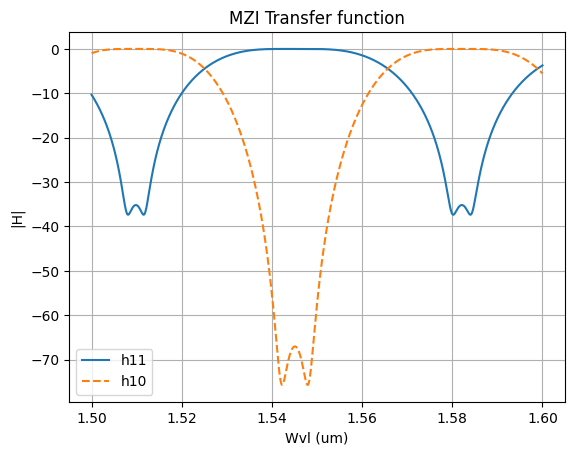

In [42]:
# Plot
plt.figure()
plt.plot(wvl, 10*np.log10(np.abs(h11_s3)**2), linestyle="-", label=f"h11")
plt.plot(wvl, 10*np.log(np.abs(h10_s3)**2), linestyle="--", label=f"h10")
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()

### Definición y simulación de todo el circuito

In [43]:


mziCascS1, info = sax.circuit(
    netlist={
        "instances": {  # elementos que componen mi dispositivo y cual modelo le aplica
            "S1_a": "S1",
            "S1_b": "S1",
            "S1_c": "S1",
            "S2_3": "S2",
            "S2_3_s3": "S2",
            "S2_4a": "S2",
            "S2_4b": "S2",
            "S2_4_s3a": "S2",
            "S2_4_s3b": "S2",
        },
        "connections": {
            "S1_a,out1": "S1_b,in0",
            "S1_a,out0": "S1_c,in0",
            # -----------------------
            "S1_b,out1": "S2_3,in0",
            # -----------------------
            "S1_c,out0": "S2_3_s3,in1",
            # -----------------------
            "S2_3,out1": "S2_4a,in0",
            "S2_3,out0": "S2_4b,in1",
            # -----------------------
            "S2_3_s3,out1": "S2_4_s3a,in0",
            "S2_3_s3,out0": "S2_4_s3b,in1",
        },
        "ports": { # a nivel global como son mis puertos 
            "in0": "S1_a,in0",
            "in1": "S1_a,in1",
            "out1": "S2_4a,out1",
            "out2": "S2_4b,out1",            
            "out3": "S2_4_s3a,out0",
            "out4": "S2_4_s3b,out0",
            
            #"out0": "S2_4b,out1",
            #"out1": "S2_4a,out1",            
            #"out2": "S2_4_s3b,out0",
            #"out3": "S2_4_s3a,out0",
        },
    },
    models={
        "S1": S1,
        "S2": S2,
    },
)

En el artículo se nos dice que hay que definir $L_{pi}$ de la siguiente manera: 

In [44]:
L_pi_select=1.55/(2*n_eff_E0)
print(L_pi_select)

0.32558973970029864


#### Simulación del circuito

Por último simulamos el circuito teniendo en cuenta todos los parámetros hallados anteriormente

In [45]:
#Prueba con el neff que es para la w --> mejores resultados

# Cuando en el n_eff tengo en cuenta el n_g y el D 

import jax.numpy as jnp
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

wvl = np.linspace(wavelengthIni, wavelengthFin, 1000)

neffu=n_eff_E0_w
neffd=n_eff_E0
alphau=0
alphad=0

sintonizador=-0.5
#ajuste_L2=0.265
#ajuste_L2_s2=0.1
#ajuste_l_pi=0.05
ajuste_L2=0.365
ajuste_L2_s2=0.2
ajuste_l_pi=-0.025


L2=L2+ajuste_L2
L2_s2=L2_s2+ajuste_L2_s2

L_pi_select=1.55/(2*n_eff_E0)
L_pi_select=L_pi_select+ajuste_l_pi


mzi_cascada_test_S1 = mziCascS1(
    S1_a={
        "coup_a":{"coupling":np.full(wvl.shape, K_final[0])},
        "wvg_u1":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": L1, "loss":alphau},
        "wvg_d1":{"wl":wvl, "neff":neffd, "length": L2, "loss":alphad},
        "coup_b":{"coupling":np.full(wvl.shape, K_final[1])},
        "wvg_u2":{"wl":wvl, "neff":neffd, "length": 2*L2, "loss":alphau},
        "wvg_d2":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*L1, "loss":alphad},
        "coup_c":{"coupling":np.full(wvl.shape, K_final[2])},
        "wvg_u3":{"wl":wvl, "neff":neffd, "length": 2*L2, "loss":alphau},
        "wvg_d3":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*L1+L_pi_select, "loss":alphad},
        "coup_d":{"coupling":np.full(wvl.shape, K_final[3])},
    },
    S1_b={
        "coup_a":{"coupling":np.full(wvl.shape, K_final[0])},
        "wvg_u1":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": L1, "loss":alphau},
        "wvg_d1":{"wl":wvl, "neff":neffd, "length": L2, "loss":alphad},
        "coup_b":{"coupling":np.full(wvl.shape, K_final[1])},
        "wvg_u2":{"wl":wvl, "neff":neffd, "length": 2*L2, "loss":alphau},
        "wvg_d2":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*L1, "loss":alphad},
        "coup_c":{"coupling":np.full(wvl.shape, K_final[2])},
        "wvg_u3":{"wl":wvl, "neff":neffd, "length": 2*L2, "loss":alphau},
        "wvg_d3":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*L1+L_pi_select, "loss":alphad},
        "coup_d":{"coupling":np.full(wvl.shape, K_final[3])},
    },
    S1_c={
        "coup_a":{"coupling":np.full(wvl.shape, K_final[0])},
        "wvg_u1":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": L1, "loss":alphau},
        "wvg_d1":{"wl":wvl, "neff":neffd, "length": L2, "loss":alphad},
        "coup_b":{"coupling":np.full(wvl.shape, K_final[1])},
        "wvg_u2":{"wl":wvl, "neff":neffd, "length": 2*L2, "loss":alphau},
        "wvg_d2":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*L1, "loss":alphad},
        "coup_c":{"coupling":np.full(wvl.shape, K_final[2])},
        "wvg_u3":{"wl":wvl, "neff":neffd, "length": 2*L2, "loss":alphau},
        "wvg_d3":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*L1+L_pi_select, "loss":alphad},
        "coup_d":{"coupling":np.full(wvl.shape, K_final[3])},
    },
    S2_3={
        "coup_a":{"coupling":np.full(wvl.shape, K_final[0])},
        "wvg_u1":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": L1_s2, "loss":alphau},
        "wvg_d1":{"wl":wvl, "neff":neffd, "length": L2_s2, "loss":alphad},
        "coup_b":{"coupling":np.full(wvl.shape, K_final[4])},
        "wvg_u2":{"wl":wvl, "neff":neffd, "length": 2*L2_s2, "loss":alphau},
        "wvg_d2":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*L1_s2, "loss":alphad},
        "coup_c":{"coupling":np.full(wvl.shape, K_final[3])},
    },
    S2_3_s3={
        "coup_a":{"coupling":np.full(wvl.shape, K_final[0])},
        "wvg_u1":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": L1_s2+sintonizador*L_pi_select, "loss":alphau},
        "wvg_d1":{"wl":wvl, "neff":neffd, "length": L2_s2, "loss":alphad},
        "coup_b":{"coupling":np.full(wvl.shape, K_final[4])},
        "wvg_u2":{"wl":wvl, "neff":neffd, "length": 2*(L2_s2), "loss":alphau},
        "wvg_d2":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*(L1_s2+sintonizador*L_pi_select), "loss":alphad},
        "coup_c":{"coupling":np.full(wvl.shape, K_final[3])},
    },
    S2_4a={
        "coup_a":{"coupling":np.full(wvl.shape, K_final[0])},
        "wvg_u1":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": L1_s2, "loss":alphau},
        "wvg_d1":{"wl":wvl, "neff":neffd, "length": L2_s2, "loss":alphad},
        "coup_b":{"coupling":np.full(wvl.shape, K_final[4])},
        "wvg_u2":{"wl":wvl, "neff":neffd, "length": 2*L2_s2, "loss":alphau},
        "wvg_d2":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*L1_s2, "loss":alphad},
        "coup_c":{"coupling":np.full(wvl.shape, K_final[3])},
    },
    S2_4b={
        "coup_a":{"coupling":np.full(wvl.shape, K_final[0])},
        "wvg_u1":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": L1_s2, "loss":alphau},
        "wvg_d1":{"wl":wvl, "neff":neffd, "length": L2_s2, "loss":alphad},
        "coup_b":{"coupling":np.full(wvl.shape, K_final[4])},
        "wvg_u2":{"wl":wvl, "neff":neffd, "length": 2*L2_s2, "loss":alphau},
        "wvg_d2":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*L1_s2, "loss":alphad},
        "coup_c":{"coupling":np.full(wvl.shape, K_final[3])},
    },
    S2_4_s3a={
        "coup_a":{"coupling":np.full(wvl.shape, K_final[0])},
        "wvg_u1":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": L1_s2+sintonizador*L_pi_select, "loss":alphau},
        "wvg_d1":{"wl":wvl, "neff":neffd, "length": L2_s2, "loss":alphad},
        "coup_b":{"coupling":np.full(wvl.shape, K_final[4])},
        "wvg_u2":{"wl":wvl, "neff":neffd, "length": 2*(L2_s2), "loss":alphau},
        "wvg_d2":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*(L1_s2+sintonizador*L_pi_select), "loss":alphad},
        "coup_c":{"coupling":np.full(wvl.shape, K_final[3])},
    },
    S2_4_s3b={
        "coup_a":{"coupling":np.full(wvl.shape, K_final[0])},
        "wvg_u1":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": L1_s2+sintonizador*L_pi_select, "loss":alphau},
        "wvg_d1":{"wl":wvl, "neff":neffd, "length": L2_s2, "loss":alphad},
        "coup_b":{"coupling":np.full(wvl.shape, K_final[4])},
        "wvg_u2":{"wl":wvl, "neff":neffd, "length": 2*(L2_s2), "loss":alphau},
        "wvg_d2":{"wl":wvl, "neff":neffu, "n_g":n_g_E0_w,"D":D_E0_w, "length": 2*(L1_s2+sintonizador*L_pi_select), "loss":alphad},
        "coup_c":{"coupling":np.full(wvl.shape, K_final[3])},
    },
)

out_1 = mzi_cascada_test_S1["in0", "out1"]
out_2 = mzi_cascada_test_S1["in0", "out2"]
out_3 = mzi_cascada_test_S1["in0", "out3"]
out_4 = mzi_cascada_test_S1["in0", "out4"]

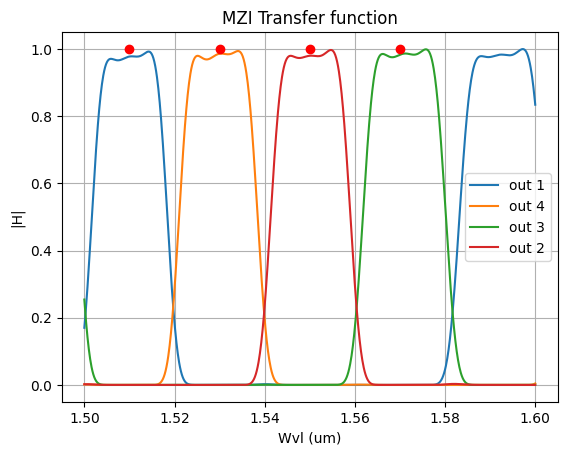

In [46]:
# Plot
plt.figure()
plt.plot(wvl, np.abs(out_1)**2, linestyle="-", label=f"out 1") #azul
plt.plot(wvl, np.abs(out_4)**2, linestyle="-", label=f"out 4") #naranja
plt.plot(wvl, np.abs(out_3)**2, linestyle="-", label=f"out 3") #verde
plt.plot(wvl, np.abs(out_2)**2, linestyle="-", label=f"out 2") #rojo
plt.plot(1.51, 1,'o', color='r')
plt.plot(1.53, 1,'o', color='r')
plt.plot(1.55, 1,'o', color='r')
plt.plot(1.57, 1,'o', color='r')
#plt.plot(wvl, H22, linestyle='-', color=color[1], label='H22')
#plt.plot(wvl, H21, linestyle='--', color=color[1], label='H21')
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()

Para poder visualizar mejor cual debe ser la señal central de cada una de las salidas, se les añadío ese punto rojo que sirve como referencia

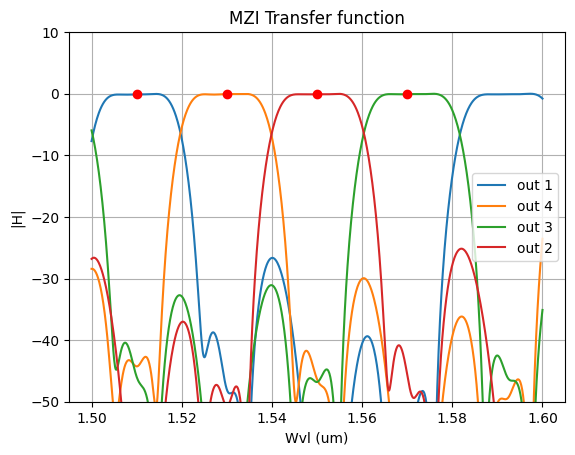

In [47]:
# Plot
plt.figure()
plt.plot(wvl, 10*np.log10(np.abs(out_1)**2), linestyle="-", label=f"out 1")
plt.plot(wvl, 10*np.log10(np.abs(out_4)**2), linestyle="-", label=f"out 4")
plt.plot(wvl, 10*np.log10(np.abs(out_3)**2), linestyle="-", label=f"out 3")
plt.plot(wvl, 10*np.log10(np.abs(out_2)**2), linestyle="-", label=f"out 2")
plt.plot(1.51, 0,'o', color='r')
plt.plot(1.53, 0,'o', color='r')
plt.plot(1.55, 0,'o', color='r')
plt.plot(1.57, 0,'o', color='r')
plt.ylim(-50,10)
plt.xlabel('Wvl (um)')
plt.legend()
plt.ylabel('|H|')
plt.title('MZI Transfer function')
plt.grid(True)
plt.show()